# Project Context - Goal - Method

In The financial sector, Surveys are regularly conducted to see how market participants feel about the current period, either being :
- *Risk on* period : they are more willing to take on risk for higher returns in equities, emerging markets and speculative investments.
- *Risk off* Period : They are less willing to take on risk and thus invest in safe haven assets like bonds of certain countries like the US, Germany or switzerland, gold etc...

We have a Semi-supervised task, where we are trying to perform anomaly detection or more precisely Novelty detection on whether current conditions imply a risk on or risk off period using a rich panel dataset of  financial data with a labeling of Risk-on/off for the particular day based on the surveys, this will be used for evaluation and benchmarking.

Inherently, the idea of our approach is that **Markets are Forward Looking**, Believing in some form of Efficient Market Hypothesis, The prices of financial assets incorporate information about future expectations on these assets by investors, we will allude to this fact many times during our project. Believing also in some form of Boom-Bust reflexive relationship - the kind famously described by George Soros - between assets and expectations. we aim to provide an novelty detection using this framework.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visualization settings
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.5)


In [2]:
file_path = './Dataset4_EWS.xlsx'

plt.rcParams['figure.figsize'] = [10, 6]

# load the data 
data_df = pd.read_excel(file_path, sheet_name='Markets')
metadata_df = pd.read_excel(file_path, sheet_name='Metadata')

# Structure of the loaded data
print("Data columns:", data_df.columns.tolist())

# Extract date and anomaly label columns
date_col = 'Date' if 'Date' in data_df.columns else data_df.columns[0]
y_col = 'Y' if 'Y' in data_df.columns else None

# Convert dates to datetime format
data_df[date_col] = pd.to_datetime(data_df[date_col], dayfirst=True)  # Date format is dd/mm/yy
data_df = data_df.set_index(date_col)

# Extract features 
if y_col:
    X_df = data_df.drop(y_col, axis=1)
    y = data_df[y_col].values
else:
    X_df = data_df
    y = None

# Display dataset info
print(f"Data shape: {X_df.shape}")
print(f"Total number of records: {len(X_df)}")
print(f"Time period: from {X_df.index.min().strftime('%m/%d/%Y')} to {X_df.index.max().strftime('%m/%d/%Y')}")
print(f"Frequency: {pd.infer_freq(X_df.index) or 'Weekly'}")
print(f"Number of variables: {X_df.shape[1]}")
if y_col:
    print(f"Number of anomalies: {np.sum(y == 1)} ({np.mean(y == 1)*100:.2f}%)")


enhanced_metadata = []
ticker_col = 'ticker' if 'ticker' in metadata_df.columns else metadata_df.columns[0]
desc_col = 'description' if 'description' in metadata_df.columns else metadata_df.columns[1] if len(metadata_df.columns) > 1 else ticker_col

for ticker in X_df.columns:
    meta_row = metadata_df[metadata_df[ticker_col] == ticker] if ticker in metadata_df[ticker_col].values else pd.DataFrame()

    # Get description or use ticker if not found
    description = meta_row[desc_col].values[0] if not meta_row.empty and desc_col in meta_row.columns else ticker

    # Calculate statistics for this series
    series = X_df[ticker]

    enhanced_metadata.append({
        'Ticker': ticker,
        'Description': description,
        'Mean': series.mean(),
        'Std.Dev': series.std(),
        'Min': series.min(),
        'Max': series.max(),
        'Missing values': series.isna().sum(),
        'Missing (%)': f"{series.isna().mean()*100:.2f}%"
    })

# Create enhanced metadata dataframe
enhanced_meta_df = pd.DataFrame(enhanced_metadata)

# Display the enhanced metadata
print("\nMetadata and statistics:")
display(enhanced_meta_df)


Data columns: ['Data', 'BDIY', 'CRY', 'Cl1', 'DXY', 'ECSURPUS', 'EMUSTRUU', 'EONIA', 'GBP', 'GT10', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y', 'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR', 'JPY', 'LF94TRUU', 'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU', 'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'US0001M', 'USGG2YR', 'USGG30YR', 'USGG3M', 'VIX', 'XAUBGNL', 'Y']
Data shape: (1111, 42)
Total number of records: 1111
Time period: from 01/11/2000 to 04/20/2021
Frequency: W-TUE
Number of variables: 42
Number of anomalies: 237 (21.33%)

Metadata and statistics:


,Ticker,Description,Mean,Std.Dev,Min,Max,Missing values,Missing (%)
0,BDIY,Baltic Dry Index,2259.860486,2017.811888,291.00000,11793.00000,0,0.00%
1,CRY,TR/CC CRB ER Index,245.247649,68.278081,106.29290,467.57000,0,0.00%
2,Cl1,Generic 1st 'CL' Future,60.708101,25.900813,10.01000,140.97000,0,0.00%
3,DXY,DOLLAR INDEX SPOT,90.934982,11.379095,71.32900,119.82000,0,0.00%
4,ECSURPUS,Bloomberg ECO US Surprise Inde,0.036153,0.349453,-0.97400,0.99100,0,0.00%
5,EMUSTRUU,EM USD Aggregate,704.379495,309.951768,230.52670,1286.35300,0,0.00%
6,EONIA,EMMI EURO OverNight Index Aver,1.363676,1.721894,-0.49800,5.73000,0,0.00%
7,GBP,British Pound Spot,1.569618,0.212340,1.17230,2.08520,0,0.00%
8,GT10,US TREASURY N/B,3.266748,1.332464,0.50800,6.74800,0,0.00%
9,GTDEM10Y,BUNDESREPUB. DEUTSCHLAND,2.448365,1.851558,-0.79400,5.64400,0,0.00%


# Different behaviour of the financial indicators during risk off

in fact for example during Risk off, we would assume a positive correlation with DXY as the markets flee to dollars, another example  would be US Equities would tend to decrease during risk off i.e a negative correlation, emerging market indexes as well.

In [3]:
def Plot_riskperiod_asset(x):
    if y_col and x in X_df.columns:
        fig, ax = plt.subplots(figsize=(14, 8))
        ax.plot(X_df.index, X_df[x], color='darkred', linewidth=2.5, label=x)
        y_min, y_max = ax.get_ylim()
        for i, (date, is_anomaly) in enumerate(zip(X_df.index, y)):
            if is_anomaly == 1:
                ax.axvspan(date, date + pd.Timedelta(days=7), alpha=0.3, color='navy', label='Risk-on/Risk-off' if i == 0 else "")
        ax.set_xlabel('Timeline')
        ax.set_ylabel(x)
        ax.set_title(x + ' and risk-on/risk-off periods')

        # Add legend
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc='best')

        plt.tight_layout()
        plt.show()
    else:
        print("Either 'Y' column or input column is missing in the dataset.")

### Emerging Markets
We would assume that Emerging markets are very sensitive and positively correlated to risk off periods, i.e they tend to have negative returns, in these periods as investors reduce their exposures.

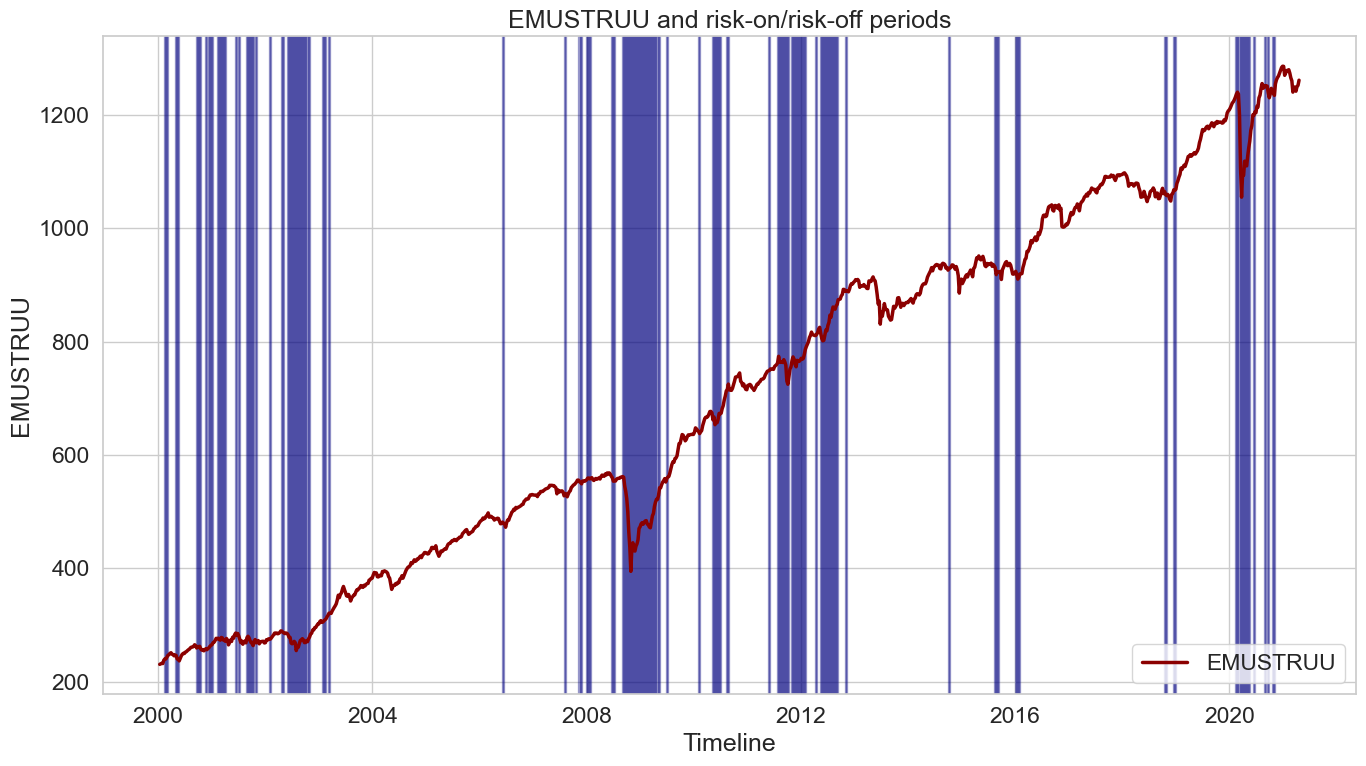

In [20]:
asset = 'EMUSTRUU'
Plot_riskperiod_asset(asset)

## The Greenback
We would assume that Dollar is somewhat sensitive and inversely correlated to risk off periods, i.e the dollar tends to have appreciate, in these periods as investors increase their exposures to safe haven assets like US government bonds.

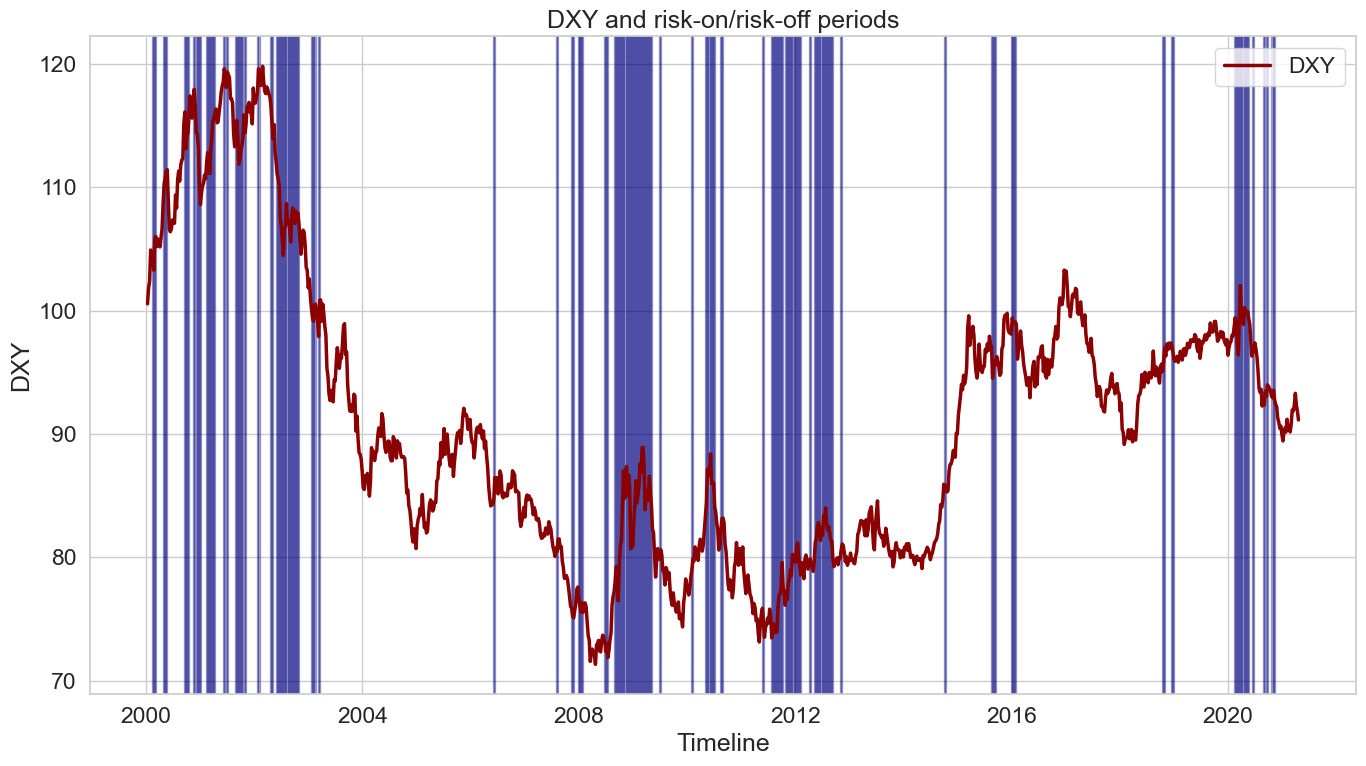

In [21]:
asset = 'DXY'
Plot_riskperiod_asset(asset)

In [22]:
data_df.head()

,BDIY,CRY,Cl1,DXY,ECSURPUS,EMUSTRUU,EONIA,GBP,GT10,GTDEM10Y,...,MXJP,MXRU,MXUS,US0001M,USGG2YR,USGG30YR,USGG3M,VIX,XAUBGNL,Y
Data,,,,,,,,,,,,,,,,,,,,,
2000-01-11,1388,157.26,25.77,100.56,0.077,230.5267,2.89,1.6460,6.657,5.541,...,990.59,224.33,1416.12,5.78125,6.428,6.671,5.426,22.50,283.25,0
2000-01-18,1405,165.01,28.85,101.86,0.043,231.3770,3.03,1.6383,6.748,5.644,...,993.98,234.37,1428.79,5.80250,6.465,6.747,5.378,21.50,287.65,0
2000-01-25,1368,167.24,28.28,102.41,0.135,232.3895,3.15,1.6496,6.692,5.515,...,974.83,216.82,1385.93,5.81875,6.432,6.634,5.562,23.02,287.15,0
2000-02-01,1311,166.85,28.22,104.92,0.191,231.9417,3.30,1.6106,6.619,5.459,...,1007.12,201.89,1385.31,5.88500,6.574,6.423,5.708,23.45,282.75,0
2000-02-08,1277,165.43,28.02,104.22,0.312,237.8117,3.26,1.6108,6.613,5.482,...,1034.58,218.00,1411.95,5.89125,6.678,6.231,5.677,21.25,298.40,1


## Return Dataset

In [23]:
indices_currencies = [col for col in X_df.columns if col in [
    'XAUBGNL', 'BDIY', 'CRY', 'Cl1', 'DXY', 'EMUSTRUU', 'GBP', 'JPY', 'LF94TRUU',
    'LF98TRUU', 'LG30TRUU', 'LMBITR', 'LP01TREU', 'LUACTRUU', 'LUMSTRUU',
    'MXBR', 'MXCN', 'MXEU', 'MXIN', 'MXJP', 'MXRU', 'MXUS', 'VIX'
]]

interest_rates = [col for col in X_df.columns if col in [
    'EONIA', 'GTDEM10Y', 'GTDEM2Y', 'GTDEM30Y', 'GTGBP20Y', 'GTGBP2Y', 'GTGBP30Y',
    'GTITL10YR', 'GTITL2YR', 'GTITL30YR', 'GTJPY10YR', 'GTJPY2YR', 'GTJPY30YR',
    'US0001M', 'USGG3M', 'USGG2YR', 'GT10', 'USGG30YR'
]]

# Create a new dataframe for stationary data
stationary_df = pd.DataFrame(index=X_df.index[1:])

# Apply log-differences to indices and currencies (always positive)
for col in indices_currencies:
    if col in X_df.columns:
        stationary_df[col] = np.diff(np.log(X_df[col]))

# Apply first differences to interest rates (can be negative or very close to 0)
for col in interest_rates:
    if col in X_df.columns:
        stationary_df[col] = np.diff(X_df[col])

# Keep Bloomberg Economic US Surprise Index as is (already stationary)
if 'ECSURPUS' in X_df.columns:
    stationary_df['ECSURPUS'] = X_df['ECSURPUS'].values[1:]

# Adjust the response variable to match the new data length
if y is not None:
    y_stationary = y[1:]
else:
    y_stationary = None

stationary_df.head()
stationary_df["Y"] = y_stationary

# Correlation : Point-Biserial Correlation
We use  daily returns  rather than raw index prices. Prices are non-stationary and generally give fake, inflated correlations.
Correlation in our case is Point-Biserial Correlation.
### Core assumptions
For this correlation to be accurate, the data must meet specific criteria:
For this correlation to be accurate, the data must meet specific criteria:
- Continuous Variable: The metric variable should be measured on an interval or ratio scale and be approximately normally distributed
- No Outliers: The continuous data should be free of extreme outliers.
- Homogeneity of Variance: The variance of the continuous variable should be roughly equal for both groups in the dichotomous variable

In [24]:
correlations = pd.DataFrame(stationary_df.corr()['Y'].sort_values())

print("Correlation with Risk-Off Regime (1):")
correlations

Correlation with Risk-Off Regime (1):


,Y
MXUS,-0.242428
LP01TREU,-0.209294
MXEU,-0.206401
GTDEM2Y,-0.200776
MXJP,-0.197236
GTGBP2Y,-0.196224
LG30TRUU,-0.178877
USGG2YR,-0.177489
LF98TRUU,-0.174037
MXBR,-0.168648


The top negative correlation we find is MXUS, which further incentivises a short thesis during risk off periods, there is also a *Self-fullfiling prophecy* component, in fact as market actors tend to believe that it is a risk off period, they reduce their exposures in US Equity markets, which drives negatives returns, this pushes other actors to also reduce their exposures as the phenomena propagates in markets.

Altough our correlations are all overall very weak, the most interesting finding is that **GT10* which is the US bond index has negative 

C:\Users\Leon\AppData\Local\Temp\ipykernel_24172\2290894098.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Y', y='DXY', data=data_df, ax=axes[0], palette='Set2')
C:\Users\Leon\AppData\Local\Temp\ipykernel_24172\2290894098.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Y', y='JPY', data=data_df, ax=axes[2], palette='Set2')


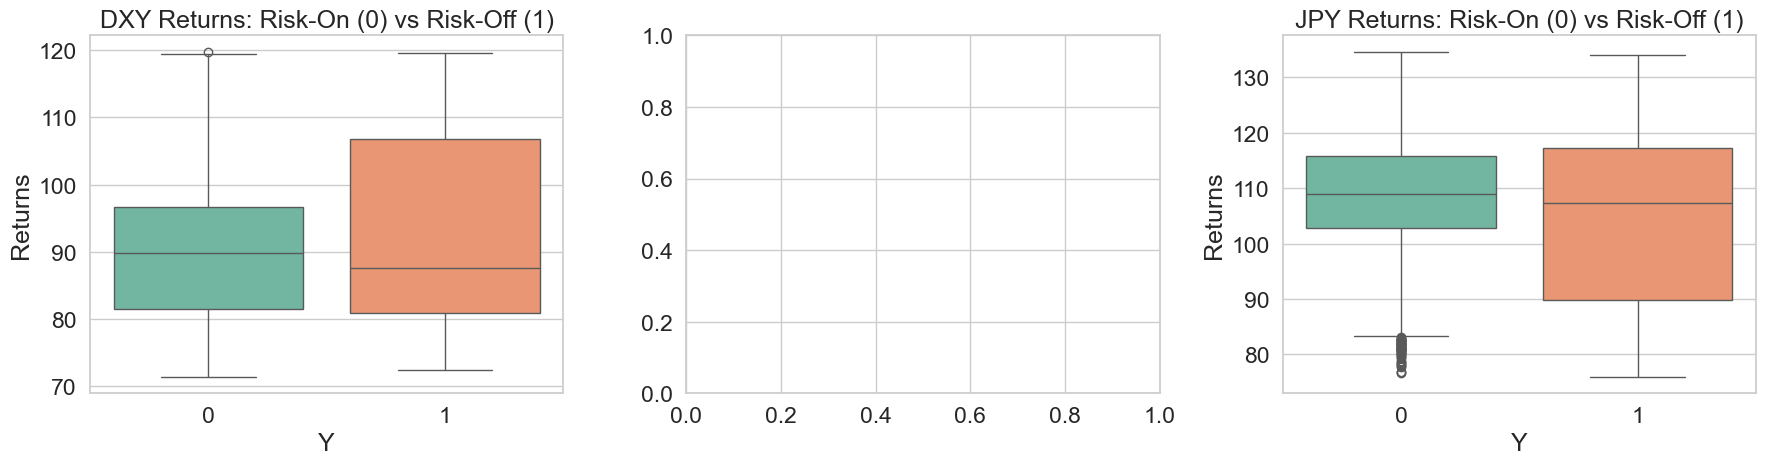

In [19]:
# Set up the plotting area
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. DXY (Expected to be higher during Risk-Off)
sns.boxplot(x='Y', y='DXY', data=data_df, ax=axes[0], palette='Set2')
axes[0].set_title('DXY Returns: Risk-On (0) vs Risk-Off (1)')
axes[0].set_ylabel('Returns')


# 3. JPY (Expected to be higher during Risk-Off)
sns.boxplot(x='Y', y='JPY', data=data_df, ax=axes[2], palette='Set2')
axes[2].set_title('JPY Returns: Risk-On (0) vs Risk-Off (1)')
axes[2].set_ylabel('Returns')

plt.tight_layout()
plt.show()

,BDIY,CRY,Cl1,DXY,EMUSTRUU,GBP,JPY,LF94TRUU,LF98TRUU,LG30TRUU,...,GTITL2YR,GTITL30YR,GTJPY10YR,GTJPY2YR,GTJPY30YR,US0001M,USGG2YR,USGG30YR,USGG3M,ECSURPUS
Data,,,,,,,,,,,,,,,,,,,,,
2000-01-18,0.012173,0.048106,0.112899,0.012845,0.003682,-0.004689,-0.003691,0.00000,-0.000660,0.000805,...,0.040,0.138,0.056,0.003,-0.004,0.02125,0.037,0.076,-0.048,0.043
2000-01-25,-0.026687,0.013424,-0.019955,0.005385,0.004366,0.006874,0.005390,0.00000,0.001867,0.002874,...,-0.024,-0.178,-0.140,-0.056,-0.159,0.01625,-0.033,-0.113,0.184,0.135
2000-02-01,-0.042560,-0.002335,-0.002124,0.024214,-0.001929,-0.023926,0.016925,-0.01165,0.001243,-0.000603,...,0.029,-0.093,0.145,0.071,0.071,0.06625,0.142,-0.211,0.146,0.191
2000-02-08,-0.026277,-0.008547,-0.007112,-0.006694,0.024993,0.000124,0.013355,0.00000,0.001588,0.011307,...,0.098,-0.070,0.149,-0.005,0.151,0.00625,0.104,-0.192,-0.031,0.312
2000-02-15,0.086946,0.024777,0.070277,0.004500,0.009644,-0.008855,-0.005229,0.00000,-0.000146,0.003551,...,0.013,0.053,-0.118,-0.026,-0.172,-0.01125,-0.050,0.015,0.063,0.391


C:\Users\Leon\AppData\Local\Temp\ipykernel_24172\4134220506.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_stationary, y='DXY', data=stationary_df, ax=axes[0], palette='Set2')
C:\Users\Leon\AppData\Local\Temp\ipykernel_24172\4134220506.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y_stationary, y='JPY', data=stationary_df, ax=axes[2], palette='Set2')


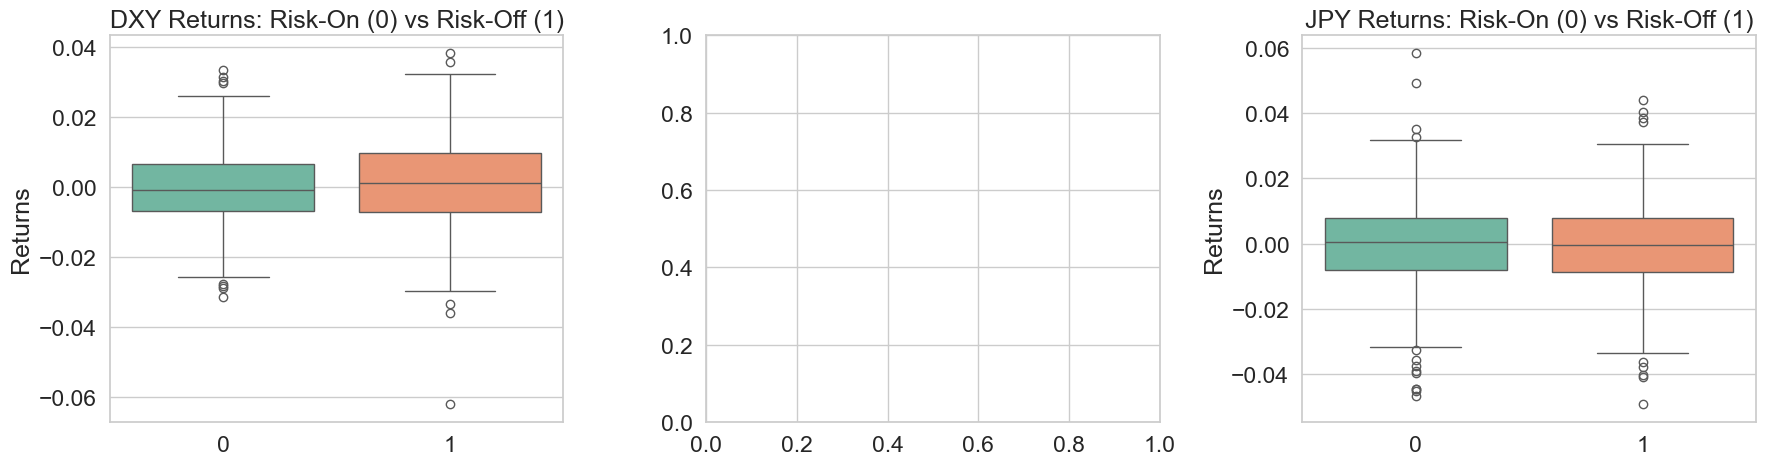

In [24]:
# Set up the plotting area
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. DXY (Expected to be higher during Risk-Off)
sns.boxplot(x=y_stationary, y='DXY', data=stationary_df, ax=axes[0], palette='Set2')
axes[0].set_title('DXY Returns: Risk-On (0) vs Risk-Off (1)')
axes[0].set_ylabel('Returns')


# 3. JPY (Expected to be higher during Risk-Off)
sns.boxplot(x=y_stationary, y='JPY', data=stationary_df, ax=axes[2], palette='Set2')
axes[2].set_title('JPY Returns: Risk-On (0) vs Risk-Off (1)')
axes[2].set_ylabel('Returns')

plt.tight_layout()
plt.show()